projeye Shamshir haye Ahanin

sakhte shode tavasot Pouriya Nouri

In [1]:
# 1. inputing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import pearsonr, ttest_ind, skew, kurtosis
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In this project, several Python libraries are used for data cleaning, preprocessing, visualization, statistical analysis, and probability distribution modeling.

In [2]:
# 2. reading csv
df=pd.read_csv('iron_swards.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


The dataset is loaded using Pandas. The first rows are displayed to understand the structure and variables.

In [3]:
df.shape

(1200, 13)

In [4]:
# 3. Remove Irrelevant Columns or Rows but we don't have any irrelevant columns or rows so we skip this step
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

The dataset contains only relevant variables. Therefore, no important column was removed.

In [5]:
# 4. df.dtypes and convert categorical columns to numric values
df.dtypes

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [6]:
df['gender']=df['gender'].replace({'male':0,'female':1})
df['platform_usage']=df['platform_usage'].map({'Instagram':0,'TikTok':1,'Both':2})
df['social_interaction_level']=df['social_interaction_level'].replace({'low':0,'medium':1,'high':2})
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,0,7.9,0,7.4,2.9,3.01,1.5,0,2,2,1,0
1,19,1,1.9,1,8.0,2.9,3.22,0.8,2,8,1,10,0
2,17,1,1.3,0,7.6,0.5,3.92,0.0,2,2,4,2,0
3,15,0,7.4,1,6.9,1.6,3.48,0.8,1,1,7,9,0
4,15,1,4.7,2,4.9,3.0,2.37,1.4,1,3,5,2,0


In [7]:
df.dtypes

age                           int64
gender                        int64
daily_social_media_hours    float64
platform_usage                int64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

Categorical variables are converted into numerical values to facilitate statistical analysis and machine learning operations.

In [8]:
# 5. Handle Missing Values but we don't have nan
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Missing values are examined before analysis. Since the dataset contains no missing values, no imputation process is required.

In [9]:
# 6. Remove Duplicate data
print("Before:",df.shape)
df=df.drop_duplicates()
print("After:",df.shape)

Before: (1200, 13)
After: (1200, 13)


Duplicate observations can negatively affect statistical results. Therefore, duplicate records are removed.

In [10]:
# 7. Normalize data
min_max_scale=MinMaxScaler()
dataminmax=pd.DataFrame(min_max_scale.fit_transform(df),columns=df.columns)
dataminmax.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,0.166667,0.0,0.985714,0.0,0.68,0.96,0.505,0.75,0.0,0.111111,0.111111,0.000000,0.0
1,1.000000,1.0,0.128571,0.5,0.80,0.96,0.610,0.40,1.0,0.777778,0.000000,1.000000,0.0
2,0.666667,1.0,0.042857,0.0,0.72,0.00,0.960,0.00,1.0,0.111111,0.333333,0.111111,0.0
3,0.333333,0.0,0.914286,0.5,0.58,0.44,0.740,0.40,0.5,0.000000,0.666667,0.888889,0.0
4,0.333333,1.0,0.528571,1.0,0.18,1.00,0.185,0.70,0.5,0.222222,0.444444,0.111111,0.0


Normalization is applied to numerical variables to bring all features into a comparable scale between 0 and 1.

In [11]:
# 8. Descriptive Statistics
df.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.487500,4.536667,0.983333,6.449417,1.740333,2.990383,1.014500,0.961667,5.445833,5.636667,5.565000,0.025833
std,2.021947,0.500052,2.029599,0.817687,1.442677,0.716660,0.576758,0.582185,0.807718,2.903290,2.859453,2.830627,0.158704
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,0.000000,2.800000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,0.000000,4.500000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,1.000000,6.300000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000


Descriptive statistics provide an overview of the dataset, including measures of central tendency and dispersion.

In [12]:
# 9. Skewness
for column in df.columns:
    print(f"Skewness of {column}: {skew(df[column])}")

Skewness of age: 0.01719334250751714
Skewness of gender: 0.05001563232803551
Skewness of daily_social_media_hours: 0.009160467477131118
Skewness of platform_usage: 0.030658845772087676
Skewness of sleep_hours: 0.01679450252059001
Skewness of screen_time_before_sleep: 0.010931911300170344
Skewness of academic_performance: 0.0436476119715531
Skewness of physical_activity: -0.05477314792099238
Skewness of social_interaction_level: 0.06970771877212058
Skewness of stress_level: 0.04757084075779842
Skewness of anxiety_level: -0.03620592164552144
Skewness of addiction_level: -0.042387163510367414
Skewness of depression_label: 5.977975895831522


Skewness measures the asymmetry of data distribution.

In [13]:
# 10. Kurtosis
for column in df.columns:
    print(f"Kurtosis of {column}: {kurtosis(df[column])}")

Kurtosis of age: -1.263539071919158
Kurtosis of gender: -1.997498436522827
Kurtosis of daily_social_media_hours: -1.1880723574926872
Kurtosis of platform_usage: -1.5024903938001652
Kurtosis of sleep_hours: -1.1892771262024675
Kurtosis of screen_time_before_sleep: -1.1653425764615097
Kurtosis of academic_performance: -1.2055321997113069
Kurtosis of physical_activity: -1.1753262171839014
Kurtosis of social_interaction_level: -1.4627711982720062
Kurtosis of stress_level: -1.2151203502450476
Kurtosis of anxiety_level: -1.2213246145539294
Kurtosis of addiction_level: -1.1980840965059287
Kurtosis of depression_label: 33.7361958111427


Kurtosis measures the peakedness of a distribution.

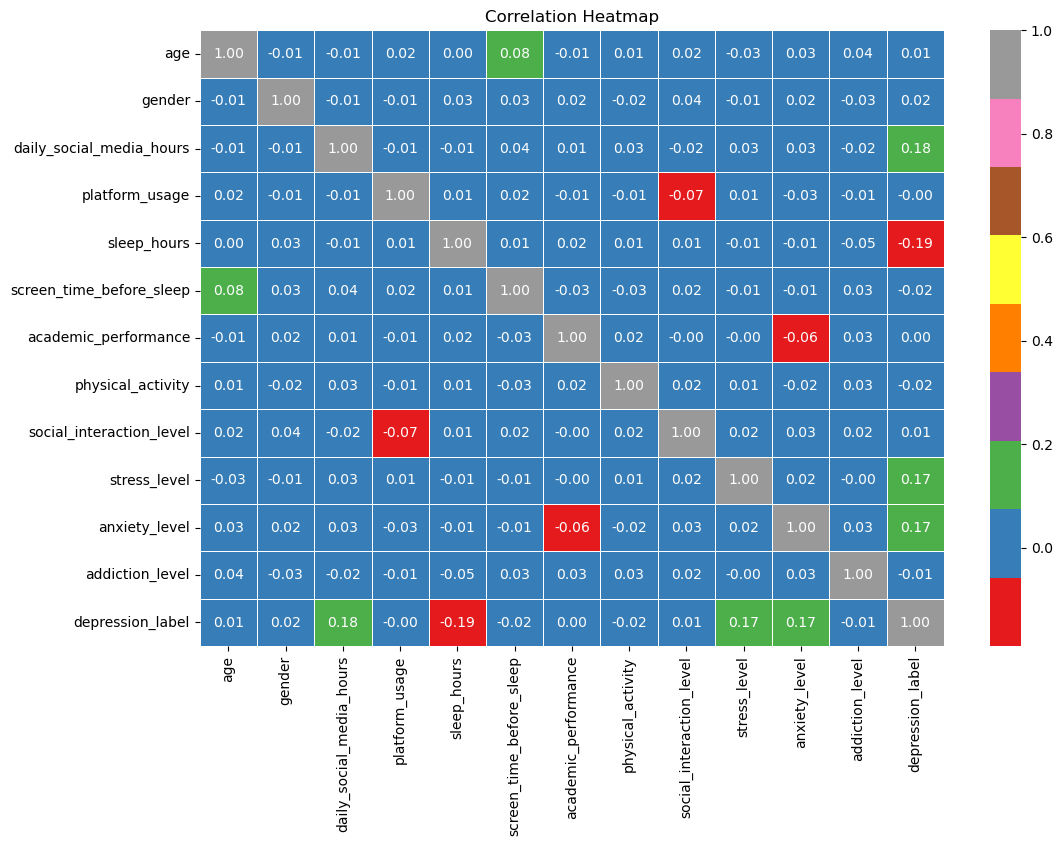

In [14]:
# 11. Correlation Analysis
corr_mat=df.corr()
plt.figure(figsize=(12,8))
sb.heatmap(corr_mat,annot=True,cmap='Set1',linewidths=0.5,fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Heatmap is used to visualize the correlation between all numerical variables.

Observation: The heatmap indicates a positive relationship between daily social media usage and mental health indicators such as stress and anxiety. Strong correlations suggest that these variables may influence each other.

In [15]:
# 12. Pearson Correlation Coefficient
p_value,p_coef=pearsonr(df['daily_social_media_hours'],df['depression_label'])
print(f"Pearson Correlation Coefficient: {p_coef}, P-value: {p_value}")

Pearson Correlation Coefficient: 9.955179654270697e-10, P-value: 0.17520080737524032


Pearson correlation is used to measure the linear relationship between social media usage and depression.

In [16]:
# 13. T-test
group1=df[df['depression_label']==0]['daily_social_media_hours']
group2=df[df['depression_label']==1]['daily_social_media_hours']
t_stat,p_value=ttest_ind(group1,group2)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -6.159342552049857, P-value: 9.95517965427257e-10


Independent T-Test is conducted to compare social media usage between depressed and non-depressed groups.

In [17]:
# baraye inke etelaat nemoudar behtar bashad mojadad farakhani kardim ke gheyr adad ham bashad
df=pd.read_csv('iron_swards.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


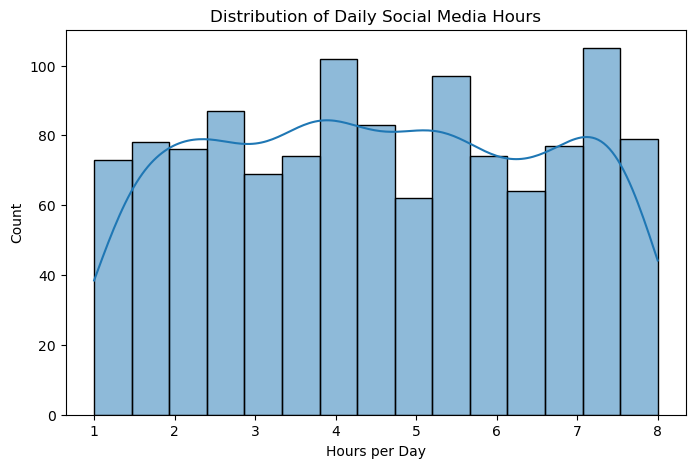

In [18]:
# 14. Histogram and KDE
plt.figure(figsize=(8,5))
sb.histplot(df['daily_social_media_hours'],bins=15,kde=True)
plt.title('Distribution of Daily Social Media Hours')
plt.xlabel('Hours per Day')
plt.ylabel('Count')
plt.show()

Histogram with kernel density estimation(KDE) is used to examine the distribution pattern of daily social media usage.

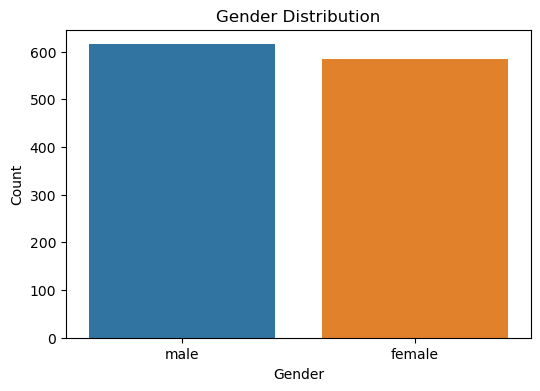

In [19]:
# 15. Countplot
# I. Gender
plt.figure(figsize=(6,4))
sb.countplot(data=df,x='gender',hue='gender')
plt.title("Gender Distribution")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Count plot illustrates the frequency distribution of gender categories.

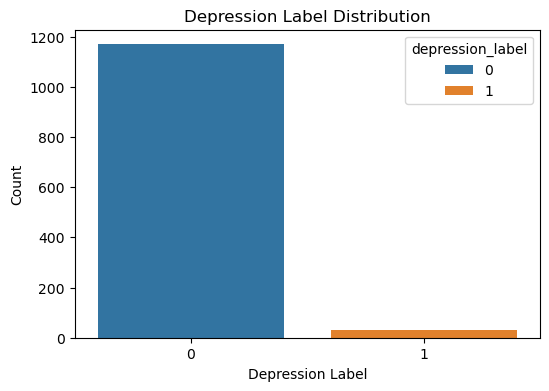

In [20]:
# II.Depression Label
plt.figure(figsize=(6,4))
sb.countplot(data=df,x='depression_label',hue='depression_label')
plt.title('Depression Label Distribution')
plt.xlabel('Depression Label')
plt.ylabel('Count')
plt.show()

Count plot shows the number of depressed and non-depressed individuals in the datadset.

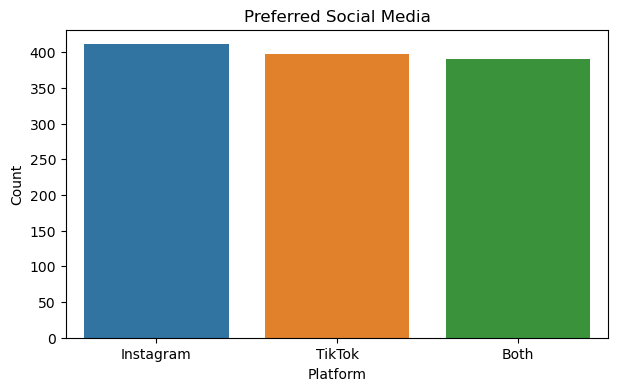

In [21]:
# III.Preferred Social Media Platform
plt.figure(figsize=(7,4))
sb.countplot(data=df,x='platform_usage',hue='platform_usage')
plt.title('Preferred Social Media')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.show()

The count plot presents the distribution of the preferred social media platform.

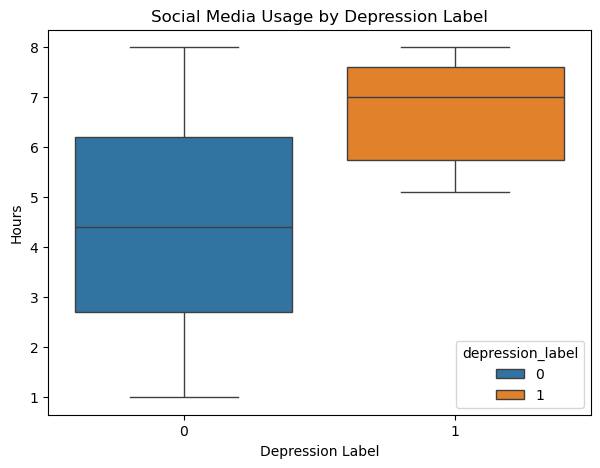

In [22]:
# 16. Boxplot for Social Media Usage by Depression Label
plt.figure(figsize=(7,5))
sb.boxplot(data=df,x='depression_label',y='daily_social_media_hours',hue='depression_label')
plt.title('Social Media Usage by Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Hours')
plt.show()

Box plot compares daily social media usage between depressed and non-depressed groups.

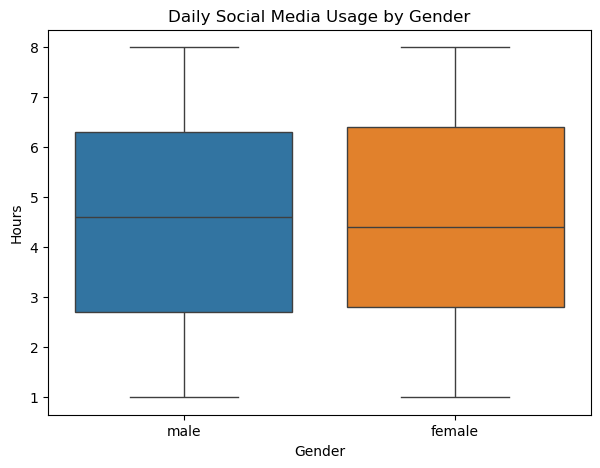

In [23]:
# 17. Boxplot for Gender
plt.figure(figsize=(7,5))
sb.boxplot(data=df,x='gender',y='daily_social_media_hours',hue='gender')
plt.title('Daily Social Media Usage by Gender')
plt.xlabel('Gender')
plt.ylabel('Hours')
plt.show()

Box plot compares the distribution of daily social media usage between genders.

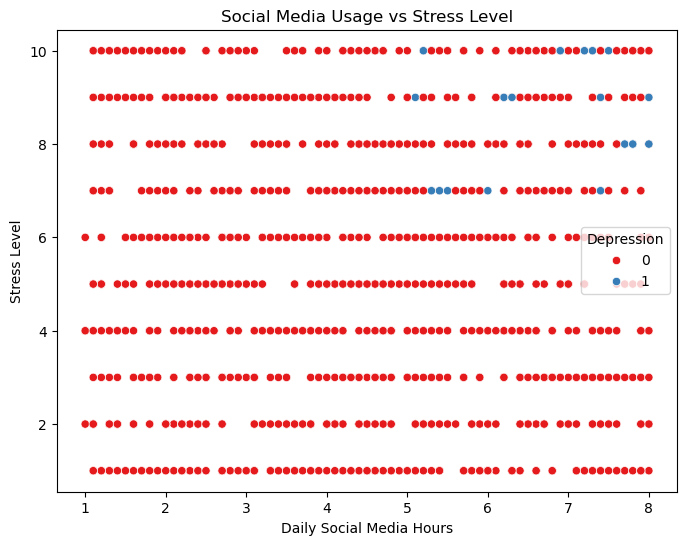

In [24]:
# 18. Scatter Plot For Depression Label
plt.figure(figsize=(8,6))

sb.scatterplot(data=df,x="daily_social_media_hours",y="stress_level",hue="depression_label",palette="Set1")
plt.title("Social Media Usage vs Stress Level")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Stress Level")
plt.legend(title="Depression")
plt.show()

Scatter plot visualizes the relationship between social media usage and stress level, while colors indicate depression status.

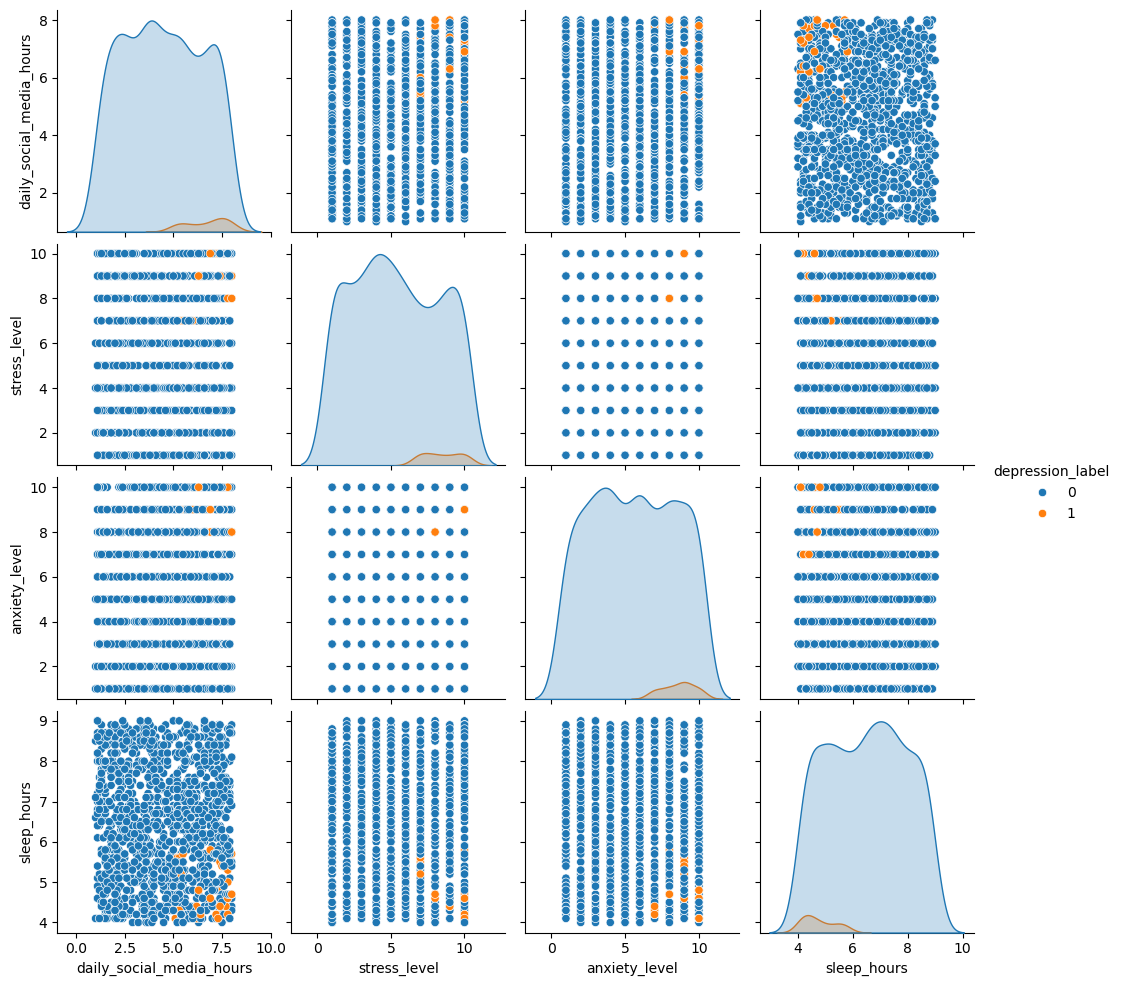

In [25]:
# 19. Pairplot
sb.pairplot(
    df[
        [
            "daily_social_media_hours",
            "stress_level",
            "anxiety_level",
            "sleep_hours",
            "depression_label"
        ]
    ],
    hue="depression_label"
)

plt.show()

Pair plot provides a comprehensive visualization of pairwise relationships among selected variables.

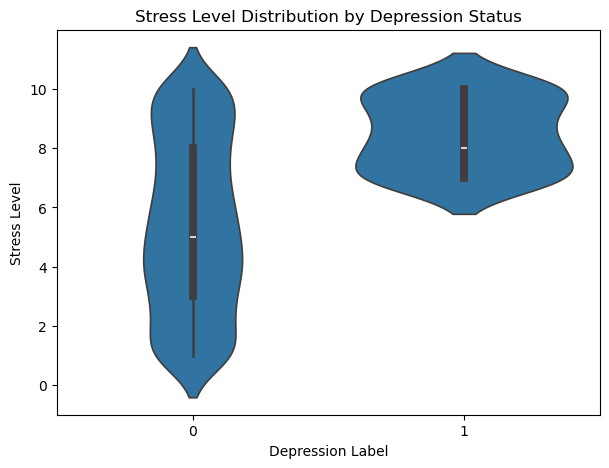

In [26]:
# 20. Violin Plot
plt.figure(figsize=(7,5))
sb.violinplot(data=df,x="depression_label",y="stress_level")
plt.title("Stress Level Distribution by Depression Status")
plt.xlabel("Depression Label")
plt.ylabel("Stress Level")
plt.show()

Violin plot combines boxplot and density estimation to illustrate the distribution of stress levels by depression status.

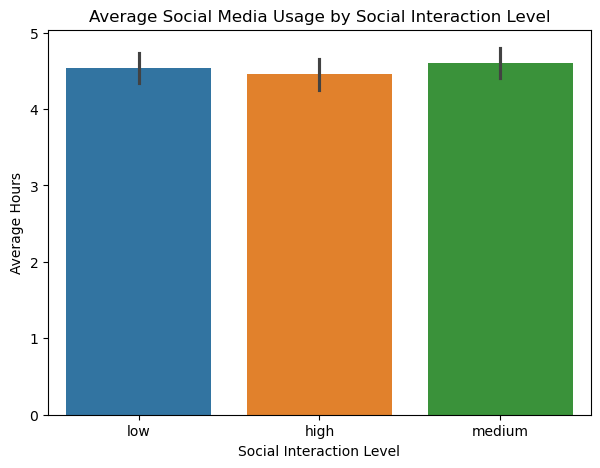

In [27]:
# 21. Barplot
plt.figure(figsize=(7,5))
sb.barplot(data=df,x="social_interaction_level",y="daily_social_media_hours",hue='social_interaction_level')
plt.title("Average Social Media Usage by Social Interaction Level")
plt.xlabel("Social Interaction Level")
plt.ylabel("Average Hours")
plt.show()

Bar plot displays the average social media usage across different levels of social interaction.

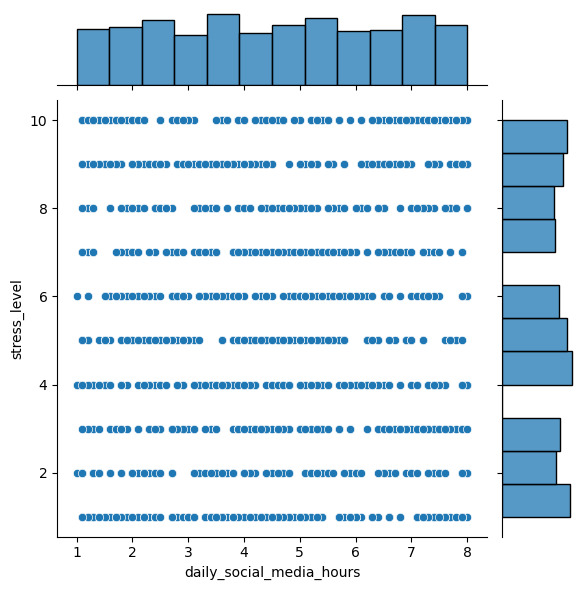

In [28]:
# 23. JointPlot
sb.jointplot(data=df,x="daily_social_media_hours",y="stress_level",kind="scatter")
plt.show()

Joint plot simultaneously displays the scatter relationship and the individual distributions of two variables.

In [29]:
# Conclusion

This project investigated the relationship between social media usage and mental health indicators among adolescents using data analysis and statistical techniques. The dataset was preprocessed through data cleaning, duplicate removal, data type conversion, and normalization to ensure reliable analysis.

Exploratory data analysis and visualization revealed meaningful patterns within the dataset. Histograms, box plots, count plots, scatter plots, and heatmaps provided a clear understanding of the distribution of variables and the relationships between them. In particular, the visualizations suggested that higher daily social media usage tends to be associated with increased levels of stress, anxiety, and depression.

Correlation analysis was performed to measure the strength of relationships between variables, while the independent T-test was used to compare groups with different depression statuses. The statistical results indicated that there are noticeable differences between depressed and non-depressed individuals regarding their social media usage behavior.

In addition, skewness and kurtosis measures helped evaluate the shape of the data distributions, and several probability distributions, including Normal, Binomial, Poisson, Uniform, and Bernoulli distributions, were generated to illustrate fundamental statistical concepts and compare theoretical distributions with real-world data.

Overall, the findings suggest that excessive social media engagement may be linked to negative mental health outcomes. Although this analysis does not establish causation, it highlights important associations that could be useful for further psychological, educational, and social research. The project also demonstrates how data preprocessing, statistical analysis, and visualization techniques can be effectively combined to extract meaningful insights from real-world datasets.